In [5]:
import os
import numpy as np
import tifffile as tiff
import nd2
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import cv2
from scipy.ndimage import center_of_mass, label


In [6]:
WF_tiles = [2,5,8,11,14,17,20,23]
dOPM_tiles = [0,1,2,3,4,5,6,7]

In [7]:
# Base directory and output directory
output_directory = r'D:\data\final_temp_240326_live_Emerald_photobleaching_plate\analysis_v2\Total_Signals_faster_no_labels'

directories = {
    "dOPM": (r"D:\data\final_temp_240326_live_Emerald_photobleaching_plate\dOPM\fused_binning_2",  dOPM_tiles),
    "WF": (r"D:\data\final_temp_240326_live_Emerald_photobleaching_plate\WF",WF_tiles)
}

# directories = {
#     "WF": (r"D:\data\final_temp_240326_live_Emerald_photobleaching_plate\WF",WF_tiles)
# }

# Directory containing the total signal CSV files
total_signals_directory = output_directory
save_path = os.path.join(output_directory, r'normalisd_signal_plots.png')


Specifying the bounding box, background offsets, time crop due to laser cut-out

In [8]:
# Usage example - based on organoid size and dOPM & WF voxels
# Specify the xy_size and z_size as per your requirements
xy_size_wf = 300  # example value 0.108 um pixel
z_size_wf = 50   # 1 um zstep
xy_size_dopm = 50 # 0.69 um pixel - choose this size as it fits comforably within all organoids
z_size_dopm = 50 # isotropic voxels
camera_offset = 100       

# Thresholds for signal - based on manual threshold for MIPS of organoids, does not cut on at edges but gives centroiding a goodstart, could replace with otsu
wf_threshold = 1500  # Threshold for WF data
dopm_threshold = 500  # Threshold for dOPM data

time_step_end = 300 # based on when dOPM 488 laser cut out
stop_time = 300

SLOW - This code goes through the 16 sets of time series, 8 dOPM, 8 WF, gets centroid of binary area, puts bounding box there and extracts total signal parallelise over tiles - SLOW

inputs - 3D images, outputs text file time vs signal - FAST - This code goes through the 16 sets of time series, 8 dOPM, 8 WF, gets centroid of binary area, puts bounding box there and extracts total signal parallelise over times - FAST

In [5]:
import os
import numpy as np
import pandas as pd
from scipy.ndimage import label, center_of_mass
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import tifffile as tiff
import nd2
import cv2

# Function to list files in a directory matching a specific pattern
def list_files(directory, pattern):
    """List files in a directory that match a specific pattern."""
    return [os.path.join(directory, file) for file in os.listdir(directory) if pattern in file]

# Function to calculate the centroid of the largest connected region in a 3D volume
def calculate_volume_centroid(z_stack, threshold):
    """Calculate the centroid of the largest connected region in the volume above the threshold."""
    binary_mask = z_stack > threshold
    if not binary_mask.any():  # Check if the binary mask is completely False
        return None
    
    # Label connected components with full connectivity
    # labeled_mask, num_features = label(binary_mask, structure=np.ones((3, 3, 3)))

    # if num_features == 0:
    #     return None

    # Find the largest connected component
    # largest_region = max(range(1, num_features + 1), key=lambda x: np.sum(labeled_mask == x))

    # Create a mask for the largest region
    # largest_region_mask = labeled_mask == largest_region
    
    # Calculate the centroid of the largest region
    # centroid = center_of_mass(largest_region_mask)
    centroid = center_of_mass(binary_mask)
    
    return centroid

# Function to extract a 3D subvolume centered around a centroid
def extract_subvolume(z_stack, centroid, xy_size, z_size):
    """Extract a 3D subvolume centered around the centroid from the 3D volume."""
    if centroid is None:
        return np.array([])  # Return an empty array if centroid is None
    
    # Convert centroid coordinates to integers
    z_center, y_center, x_center = [int(coord) for coord in centroid]

    # Calculate bounds with consideration for edge cases
    half_xy_size = xy_size // 2
    y_min = max(y_center - half_xy_size, 0)
    y_max = min(y_center + half_xy_size + 1, z_stack.shape[1])
    x_min = max(x_center - half_xy_size, 0)
    x_max = min(x_center + half_xy_size + 1, z_stack.shape[2])

    half_z_size = z_size // 2
    z_min = max(z_center - half_z_size, 0)
    z_max = min(z_center + half_z_size + 1, z_stack.shape[0])

    # Extract the subvolume
    subvolume = z_stack[z_min:z_max, y_min:y_max, x_min:x_max]
    return subvolume

# Function to calculate the total signal in a subvolume
def calculate_total_signal_in_subvolume(subvolume):
    """Calculate the total signal in a subvolume."""
    subvolume = subvolume - camera_offset
    if subvolume is None:
        return 0
    return np.sum(subvolume, dtype=np.float32)

# Function to process a single time point within a tile
def process_time_point(file_path, time_point, threshold, xy_size, z_size):
    """Process a single time point for a given tile."""
    # Load the z-stack
    if file_path.endswith('.nd2'):
        z_stack = nd2.imread(file_path)
    else:
        z_stack = tiff.imread(file_path)
    
    # Calculate the centroid
    centroid = calculate_volume_centroid(z_stack, threshold)
    if centroid is None:
        print(f"No valid centroid found for {file_path}; skipping.")
        return None, None
    
    # Extract the subvolume
    subvolume = extract_subvolume(z_stack, centroid, xy_size, z_size)
    if subvolume.size == 0:
        print(f"Subvolume is empty for {file_path}; skipping.")
        return None, None
    
    # Calculate the total signal in the subvolume
    total_signal = calculate_total_signal_in_subvolume(subvolume)
    
    return time_point, total_signal

# Function to process a single tile's data, parallelizing over time points
def process_tile_parallel(dataset_type, dir_path, tile, output_directory, threshold, xy_size, z_size):
    full_dir_path = dir_path
    is_nd = dataset_type == "WF"
    file_extension = '.nd2' if is_nd else '.tif'
    
    total_signals = {'Timepoint': [], 'Total Signal': []}
    
    time_point_files = []
    for time_point in range(time_step_end):
        pattern = f"WF_Time{str(time_point).zfill(4)}_Tile{str(tile).zfill(4)}" if is_nd else f"tile_{str(tile)}_fused_tp_{str(time_point)}_ch_0"
        image_files = list_files(full_dir_path, pattern + file_extension)
        time_point_files.extend([(file_path, time_point) for file_path in image_files])
    
    with ThreadPoolExecutor(max_workers=80) as executor:
        futures = {executor.submit(process_time_point, file_path, time_point, threshold, xy_size, z_size): (file_path, time_point)
                   for file_path, time_point in time_point_files}
        
        for future in as_completed(futures):
            time_point, total_signal = future.result()
            if time_point is not None and total_signal is not None:
                total_signals['Timepoint'].append(time_point)
                total_signals['Total Signal'].append(total_signal)
    
    output_file_name = f"Total_Signal_{dataset_type}_Tile{tile}.csv"
    output_file_path = os.path.join(output_directory, output_file_name)
    df = pd.DataFrame(total_signals)
    df.to_csv(output_file_path, index=False)

# Main loop to process each tile in sequence
def process_tiles_sequentially(dataset_type, dir_path, tiles, output_directory, threshold, xy_size, z_size):
    for tile in tqdm(tiles):
        process_tile_parallel(dataset_type, dir_path, tile, output_directory, threshold, xy_size, z_size)

# Ensure output directory exists
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Process each dataset type (dOPM and WF) sequentially over tiles, parallelizing only over time points
for dataset_type, (dir_path, tiles) in directories.items():
    process_tiles_sequentially(dataset_type, dir_path, tiles, output_directory,
                               wf_threshold if dataset_type == "WF" else dopm_threshold,
                               xy_size_wf if dataset_type == "WF" else xy_size_dopm,
                               z_size_wf if dataset_type == "WF" else z_size_dopm)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [43:07<00:00, 323.43s/it]


Plot the csv data, time vs integrated signal

C:\Users\User\AppData\Local\Temp\ipykernel_18008\242738868.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  blue_cmap = get_cmap('Blues')
C:\Users\User\AppData\Local\Temp\ipykernel_18008\242738868.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  green_cmap = get_cmap('Greens')


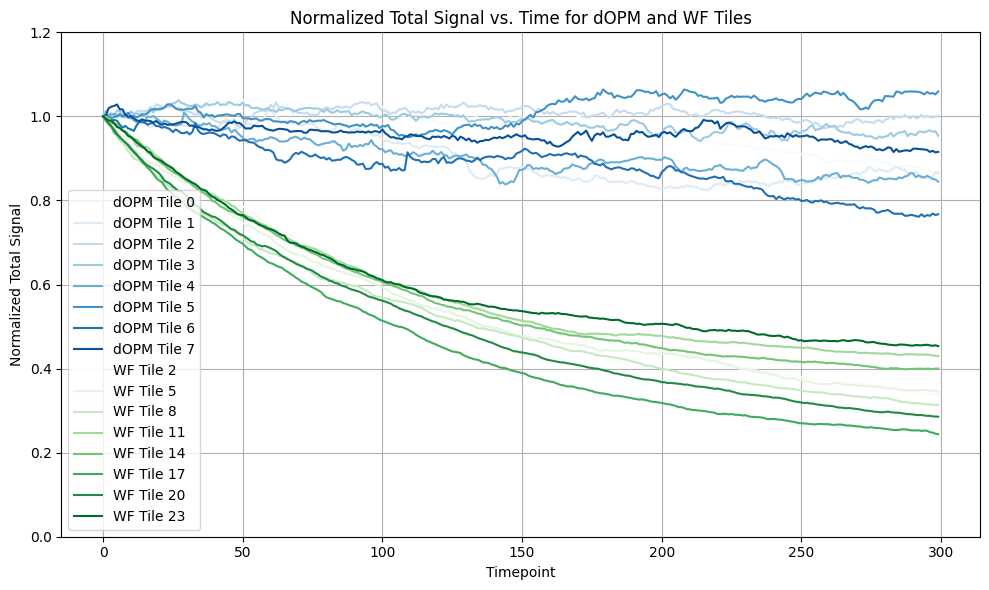

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# Function to normalize data
def normalize_data(data):
    return data / data.iloc[0]

# Number of plots
n = 8

# Get the colormap
blue_cmap = get_cmap('Blues')
green_cmap = get_cmap('Greens')

# Generate colors from the colormap
colors_dOPM = [blue_cmap(i/n) for i in range(n)]
colors_WF  = [green_cmap(i/n) for i in range(n)]

# Create a single figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Process dOPM tiles
for i, tile in enumerate(dOPM_tiles):
    # Read the total signal CSV file for the current dOPM tile
    file_path = os.path.join(total_signals_directory, f'Total_Signal_dOPM_Tile{tile}.csv')
    df = pd.read_csv(file_path)

    # Sort the data by the first column (Timepoint) in ascending order
    df = df.sort_values(by=df.columns[0])
    
    normalized_signal = normalize_data(df['Total Signal'])
    
    # Plot the total signal data for dOPM
    ax.plot(df['Timepoint'][:stop_time], normalized_signal[:stop_time], label=f'dOPM Tile {tile}', color=colors_dOPM[i])

# Process WF tiles
for i, tile in enumerate(WF_tiles):
    # Read the total signal CSV file for the current WF tile
    file_path = os.path.join(total_signals_directory, f'Total_Signal_WF_Tile{tile}.csv')
    df = pd.read_csv(file_path)
    
    # Sort the data by the first column (Timepoint) in ascending order
    df = df.sort_values(by=df.columns[0])

    normalized_signal = normalize_data(df['Total Signal'])
    
    # Plot the total signal data for WF
    ax.plot(df['Timepoint'][:stop_time], normalized_signal[:stop_time], label=f'WF Tile {tile}', color=colors_WF[i])

# Set labels and axis properties
ax.set_xlabel('Timepoint')
ax.set_ylabel('Normalized Total Signal')
ax.set_ylim([0, 1.2])
ax.set_title('Normalized Total Signal vs. Time for dOPM and WF Tiles')
ax.legend()

# Tight layout often improves the spacing between subplots
plt.grid(True)
plt.tight_layout()

# Save the figure
fig.savefig(save_path, dpi=300, bbox_inches='tight')

# Optionally, if you still want to display it after saving
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_24244\4166941780.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  magenta_cmap = get_cmap('RdPu')
C:\Users\User\AppData\Local\Temp\ipykernel_24244\4166941780.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  green_cmap = get_cmap('Greens')


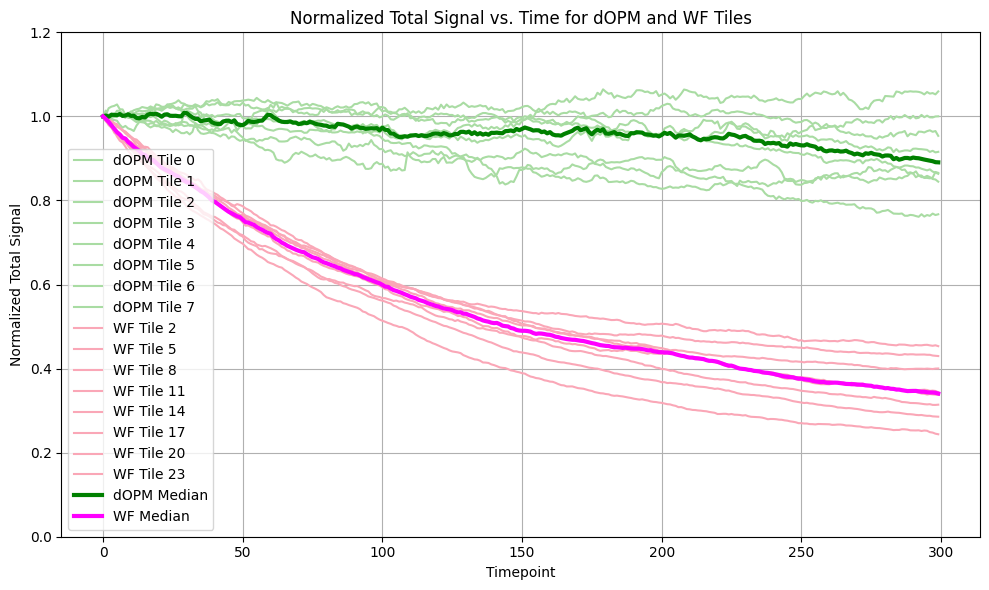

In [62]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# Function to normalize data
def normalize_data(data):
    return data / data.iloc[0]

# Number of plots
n = 8

# Get the colormap
magenta_cmap = get_cmap('RdPu')
green_cmap = get_cmap('Greens')

# Generate colors from the colormap
# colors_dOPM = [blue_cmap(i/n) for i in range(n)]
# colors_WF  = [green_cmap(i/n) for i in range(n)]
colors_WF = [magenta_cmap(0.35) for i in range(n)]
colors_dOPM = [green_cmap(0.35) for i in range(n)]

# Lists to hold data for median calculation
dOPM_data = []
WF_data = []

# Create a single figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Process dOPM tiles
for i, tile in enumerate(dOPM_tiles):
    file_path = os.path.join(total_signals_directory, f'Total_Signal_dOPM_Tile{tile}.csv')
    df = pd.read_csv(file_path)
    df = df.sort_values(by='Timepoint').reset_index(drop=True)  # Sort and reset index
    
    # Normalize the total signal
    normalized_signal = normalize_data(df['Total Signal'])

    # Append as an array
    dOPM_data.append(normalized_signal[:stop_time].values)
    
    # Plot the data
    ax.plot(df['Timepoint'][:stop_time], normalized_signal[:stop_time], label=f'dOPM Tile {tile}', color=colors_dOPM[i])

# Process WF tiles
for i, tile in enumerate(WF_tiles):
    file_path = os.path.join(total_signals_directory, f'Total_Signal_WF_Tile{tile}.csv')
    df = pd.read_csv(file_path)
    df = df.sort_values(by='Timepoint').reset_index(drop=True)  # Sort and reset index
    
    # Normalize the total signal
    normalized_signal = normalize_data(df['Total Signal'])

    # Append as an array
    WF_data.append(normalized_signal[:stop_time].values)
    
    # Plot the data
    ax.plot(df['Timepoint'][:stop_time], normalized_signal[:stop_time], label=f'WF Tile {tile}', color=colors_WF[i])

# Calculate and plot median for dOPM
dOPM_median = pd.DataFrame(dOPM_data).median(axis=0)
ax.plot(df['Timepoint'][:stop_time], dOPM_median, label='dOPM Median', color='green', linewidth=3, linestyle='-')

# Calculate and plot median for WF
WF_median = pd.DataFrame(WF_data).median(axis=0)
ax.plot(df['Timepoint'][:stop_time], WF_median, label='WF Median', color='magenta', linewidth=3, linestyle='-')

# Set labels and axis properties
ax.set_xlabel('Timepoint')
ax.set_ylabel('Normalized Total Signal')
ax.set_ylim([0, 1.2])
ax.set_title('Normalized Total Signal vs. Time for dOPM and WF Tiles')
ax.legend()

# Tight layout often improves the spacing between subplots
plt.grid(True)
plt.tight_layout()

# Save the figure
fig.savefig(save_path, dpi=300, bbox_inches='tight')

# Optionally, if you still want to display it after saving
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_24244\3503964249.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  magenta_cmap = get_cmap('RdPu')
C:\Users\User\AppData\Local\Temp\ipykernel_24244\3503964249.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  green_cmap = get_cmap('Greens')


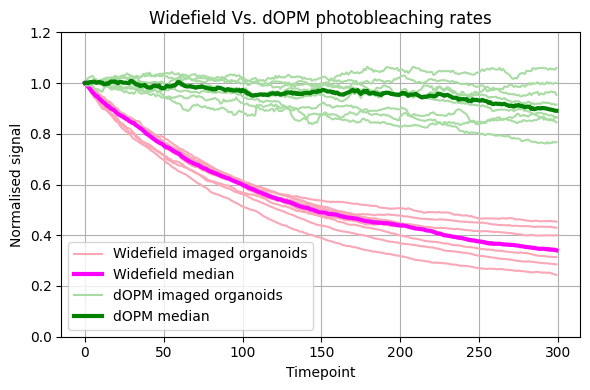

In [72]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# Function to normalize data
def normalize_data(data):
    return data / data.iloc[0]

# Number of plots
n = 8

# Get the colormap
magenta_cmap = get_cmap('RdPu')
green_cmap = get_cmap('Greens')

# Fixed colors for specific plots
color_WF_tile2 = magenta_cmap(0.35)
color_dOPM_tile0 = green_cmap(0.35)
color_WF_median = 'magenta'
color_dOPM_median = 'green'

# Lists to hold data for median calculation
dOPM_data = []
WF_data = []

# Create a single figure and axes
fig, ax = plt.subplots(figsize=(6, 4))

# Process WF tiles
for i, tile in enumerate(WF_tiles):
    file_path = os.path.join(total_signals_directory, f'Total_Signal_WF_Tile{tile}.csv')
    df = pd.read_csv(file_path)
    df = df.sort_values(by='Timepoint').reset_index(drop=True)  # Sort and reset index
    
    # Normalize the total signal
    normalized_signal = normalize_data(df['Total Signal'])

    # Append as an array
    WF_data.append(normalized_signal[:stop_time].values)
    
    # Plot the data
    if tile == 2:
        ax.plot(df['Timepoint'][:stop_time], normalized_signal[:stop_time], label='Widefield imaged organoids', color=color_WF_tile2)
    else:
        ax.plot(df['Timepoint'][:stop_time], normalized_signal[:stop_time], color=color_WF_tile2, label='_nolegend_')


# Calculate and plot median for WF
WF_median = pd.DataFrame(WF_data).median(axis=0)
ax.plot(df['Timepoint'][:stop_time], WF_median, label='Widefield median', color=color_WF_median, linewidth=3, linestyle='-')

# Process dOPM tiles
for i, tile in enumerate(dOPM_tiles):
    file_path = os.path.join(total_signals_directory, f'Total_Signal_dOPM_Tile{tile}.csv')
    df = pd.read_csv(file_path)
    df = df.sort_values(by='Timepoint').reset_index(drop=True)  # Sort and reset index
    
    # Normalize the total signal
    normalized_signal = normalize_data(df['Total Signal'])

    # Append as an array
    dOPM_data.append(normalized_signal[:stop_time].values)
    
    # Plot the data
    if tile == 0:
        ax.plot(df['Timepoint'][:stop_time], normalized_signal[:stop_time], label='dOPM imaged organoids', color=color_dOPM_tile0)
    else:
        ax.plot(df['Timepoint'][:stop_time], normalized_signal[:stop_time], color=color_dOPM_tile0, label='_nolegend_')

# Calculate and plot median for dOPM
dOPM_median = pd.DataFrame(dOPM_data).median(axis=0)
ax.plot(df['Timepoint'][:stop_time], dOPM_median, label='dOPM median', color=color_dOPM_median, linewidth=3, linestyle='-')


# Set labels and axis properties
ax.set_xlabel('Timepoint')
ax.set_ylabel('Normalised signal')
ax.set_ylim([0, 1.2])
ax.set_title('Widefield Vs. dOPM photobleaching rates')

# Set legend
ax.legend()

# Tight layout often improves the spacing between subplots
plt.grid(True)
plt.tight_layout()

# Save the figure
fig.savefig(save_path, dpi=300, bbox_inches='tight')

# Optionally, if you still want to display it after saving
plt.show()
